# Análisis de Valores Faltantes
**Proyecto:** Reconstrucción de Base de Datos Hidrometeorológica a partir de Técnicas de Inteligencia Artificial para el laboratorio de Geomática y Teledetección.   
**Fuente de datos:** Archivos parquet individuales (día por día)  
**Objetivo:** Mapeo detallado de nulos por estación, variable, mes y año. Identificación de patrones estacionales y de rachas.

## Importaciones y configuración

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## Rutas del proyecto

In [ ]:
PROJECT_ROOT = Path(r"/home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main")
INDEX_PATH   = PROJECT_ROOT / "data" / "interim" / "organized" / "estado=sin" / "_index.csv"
INTERIM_DIR  = PROJECT_ROOT / "data" / "interim" / "organized" / "estado=sin"
FIGURES_DIR  = PROJECT_ROOT / "reports" / "figures" / "analisis_valores_faltantes"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'INDEX_PATH   : {INDEX_PATH}')
print(f'FIGURES_DIR  : {FIGURES_DIR}')
print(f'Índice existe: {INDEX_PATH.exists()}')

PROJECT_ROOT : /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main
INDEX_PATH   : /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/data/interim/organized/estado=sin/_index.csv
FIGURES_DIR  : /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/figures
Índice existe: True


## 3. Carga del índice

Primero cargamos el `_index.csv` para tener el catálogo completo de archivos parquet disponibles.

In [3]:
index_df = pd.read_csv(INDEX_PATH)
index_df['station']     = index_df['station'].astype(str).str.zfill(5)
index_df['year']        = index_df['year'].astype(int)
index_df['variable']    = index_df['variable'].str.lower()
index_df['missing_pct'] = pd.to_numeric(index_df['missing_pct'], errors='coerce')

# Normalizar rutas
def normalize_path(p):
    path = Path(str(p))
    if path.exists():
        return path
    parts = path.parts
    for i, part in enumerate(parts):
        if part == 'data':
            return PROJECT_ROOT / Path(*parts[i:])
    return path

index_df['path_parquet'] = index_df['path_parquet'].apply(normalize_path)
index_df = index_df.drop_duplicates(subset=['station','year','variable']).reset_index(drop=True)

print(f'Registros en índice : {len(index_df):,}')
print(f'Estaciones únicas   : {index_df["station"].nunique()}')
print(f'Variables           : {sorted(index_df["variable"].unique())}')
print(f'Rango de años       : {index_df["year"].min()} – {index_df["year"].max()}')

Registros en índice : 19,256
Estaciones únicas   : 168
Variables           : ['evap', 'precip', 'tmax', 'tmin']
Rango de años       : 1908 – 2026


## Carga de todos los parquet

Cargamos los 19,220 archivos parquet con los registros diarios reales. Una vez cargado, todos los análisis siguientes son instantáneos.

De cada fila solo necesitamos saber si `value` es NaN o no — eso es lo que nos dice si hay dato o faltante ese día.

In [4]:
records = []
omitidos = 0

for _, row in index_df.iterrows():
    p = Path(row['path_parquet'])
    if not p.exists():
        omitidos += 1
        continue
    try:
        df = pd.read_parquet(p, columns=['date', 'value'])
        df['station']  = row['station']
        df['variable'] = row['variable']
        df['year']     = row['year']
        records.append(df)
    except Exception:
        omitidos += 1

raw_df = pd.concat(records, ignore_index=True)
raw_df['date']    = pd.to_datetime(raw_df['date'], errors='coerce')
raw_df['value']   = pd.to_numeric(raw_df['value'], errors='coerce')
raw_df['is_null'] = raw_df['value'].isna().astype(int)  # 1 = faltante, 0 = dato válido
raw_df['month']   = raw_df['date'].dt.month

print(f'Filas cargadas   : {len(raw_df):,}')
print(f'Archivos omitidos: {omitidos}')
print(f'Total faltantes  : {raw_df["is_null"].sum():,} ({raw_df["is_null"].mean()*100:.1f}%)')

Filas cargadas   : 6,405,536
Archivos omitidos: 0
Total faltantes  : 850,639 (13.3%)


## Mapeo de nulos por estación y variable

Construimos la matriz principal: cada estación × variable con su porcentaje real de días faltantes calculado desde los datos crudos.

In [5]:
missing_matrix = (
    raw_df
    .groupby(['station', 'variable'])['is_null']
    .mean()
    .mul(100)
    .round(2)
    .unstack('variable')
)

# Ordenar por promedio general (peores arriba)
missing_matrix['_mean'] = missing_matrix.mean(axis=1)
missing_matrix = missing_matrix.sort_values('_mean', ascending=False).drop(columns='_mean')

print(f'Matriz generada: {missing_matrix.shape[0]} estaciones × {missing_matrix.shape[1]} variables')
print(f'\nTop 10 estaciones con MÁS faltantes:')
print(missing_matrix.head(10).to_string())
print(f'\nTop 10 estaciones con MENOS faltantes:')
print(missing_matrix.tail(10).to_string())

Matriz generada: 168 estaciones × 4 variables

Top 10 estaciones con MÁS faltantes:
variable    evap  precip   tmax   tmin
station                               
25101      89.99    0.35  89.99  89.99
25092      79.77    0.37  79.47  79.47
25024      76.91    0.32  76.65  76.65
25085      72.12    0.36  72.16  72.16
25054      70.10    1.24  72.11  72.11
25043      71.06    0.80  71.59  71.59
25117     100.00    2.62  49.44  49.44
25002      62.08    0.08  61.68  61.68
25052      58.28    0.44  54.93  54.93
25066      53.11    0.81  57.33  57.33

Top 10 estaciones con MENOS faltantes:
variable  evap  precip  tmax  tmin
station                           
25057     0.31    0.00  0.00  0.00
25010     0.31    0.00  0.00  0.00
25068     0.14    0.03  0.06  0.06
25114     0.23    0.00  0.00  0.00
25097     0.06    0.08  0.03  0.03
25072     0.01    0.07  0.05  0.05
25190     0.14    0.00  0.00  0.00
25035     0.05    0.00  0.00  0.00
25185     0.00    0.00  0.00  0.00
25191     0.00    0.00 

## Tabla resumen por variable

Estadísticas globales de faltantes para cada variable climática.

In [6]:
resumen_var = (
    raw_df
    .groupby('variable')
    .agg(
        total_dias      = ('is_null', 'count'),
        dias_faltantes  = ('is_null', 'sum'),
        pct_faltante    = ('is_null', lambda x: round(x.mean() * 100, 2)),
        dias_validos    = ('is_null', lambda x: (x == 0).sum()),
    )
)
resumen_var['pct_valido'] = (resumen_var['dias_validos'] / resumen_var['total_dias'] * 100).round(2)

print('Resumen de faltantes por variable (nivel día):')
print(resumen_var.to_string())

Resumen de faltantes por variable (nivel día):
          total_dias  dias_faltantes  pct_faltante  dias_validos  pct_valido
variable                                                                    
evap         1601384          613640         38.32        987744       61.68
precip       1601384           10823          0.68       1590561       99.32
tmax         1601384          113088          7.06       1488296       92.94
tmin         1601384          113088          7.06       1488296       92.94


## Heatmap principal: estación × variable

Verde = datos completos (0% faltantes). Rojo = sin datos (100% faltantes).

Figura guardada en: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/figures/heatmap_faltantes_estacion_variable.png


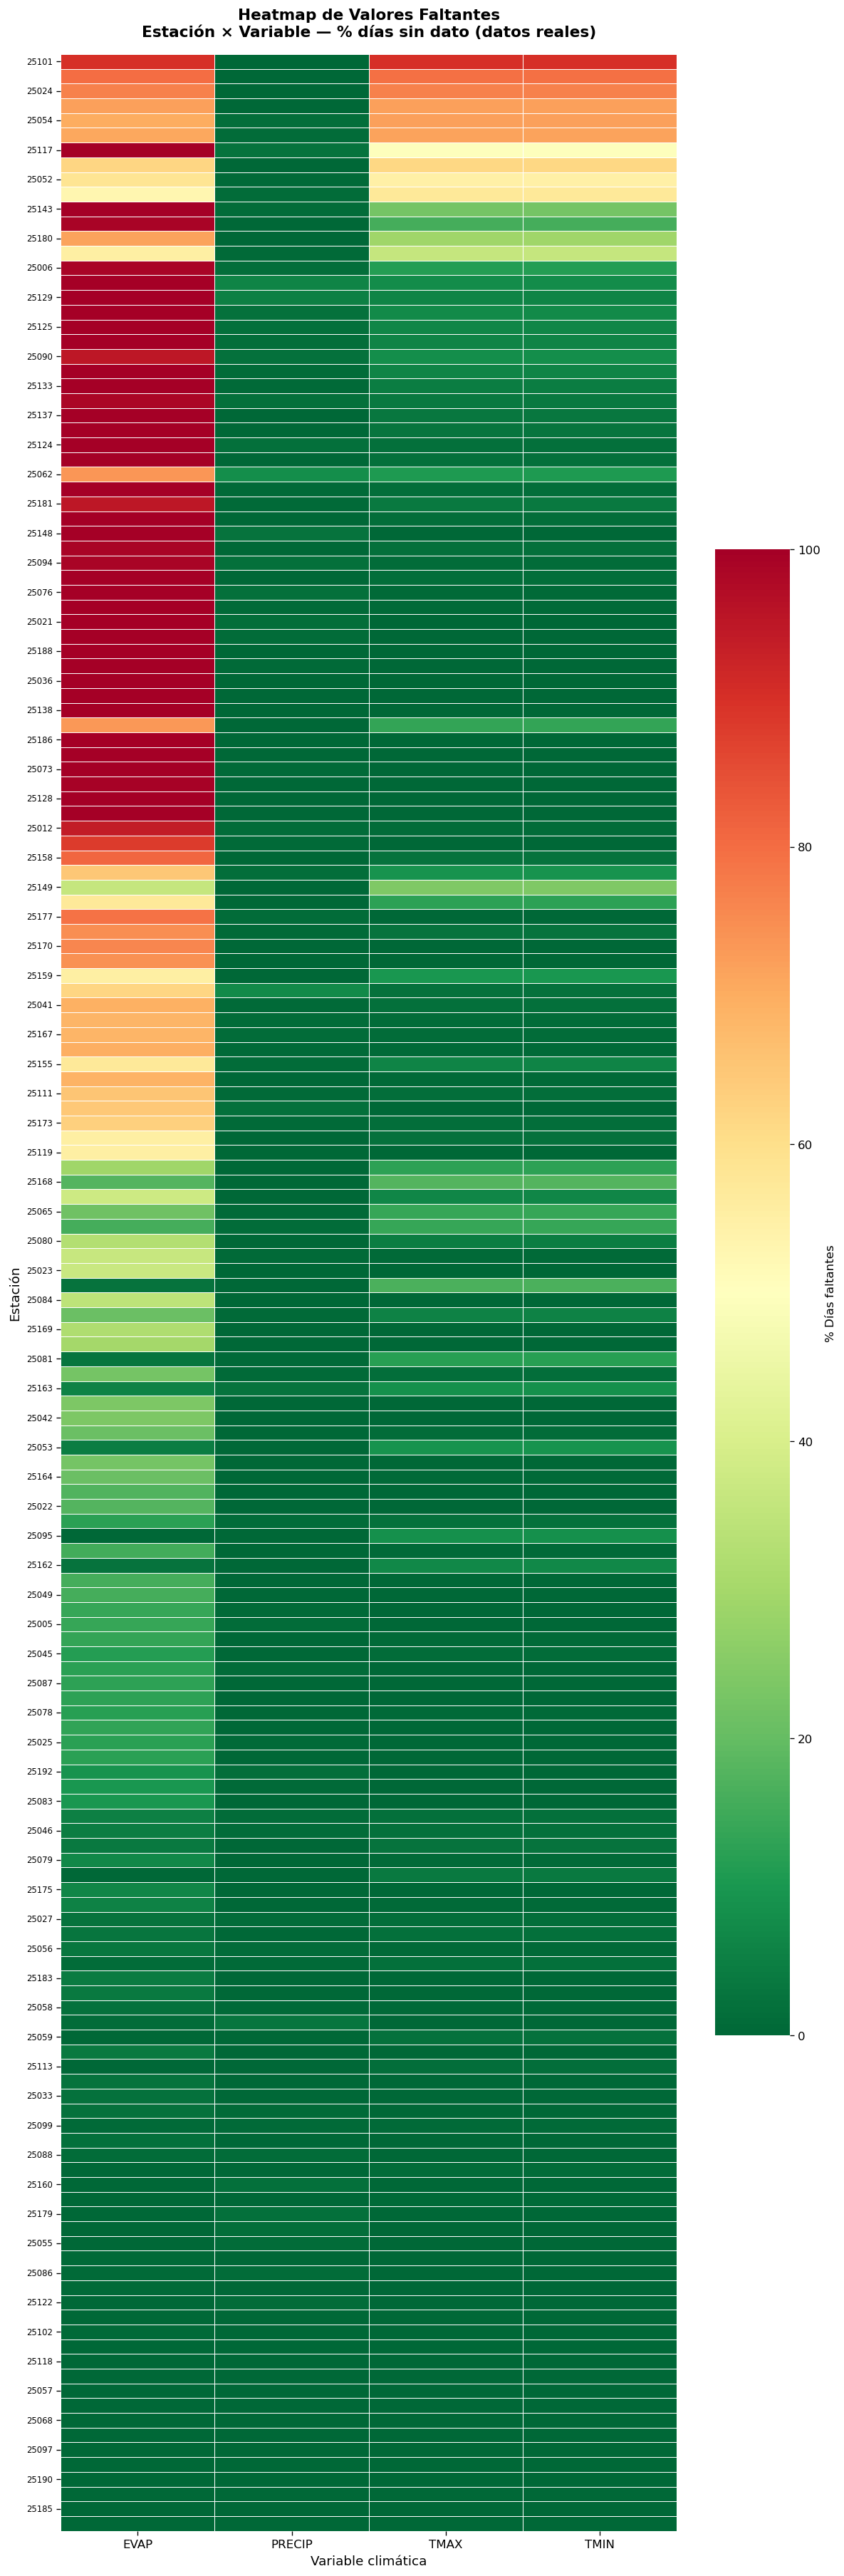

In [7]:
fig, ax = plt.subplots(figsize=(10, max(12, len(missing_matrix) * 0.18)))

sns.heatmap(
    missing_matrix,
    ax=ax,
    cmap='RdYlGn_r',
    vmin=0, vmax=100,
    linewidths=0.3,
    linecolor='white',
    annot=False,
    cbar_kws={'label': '% Días faltantes', 'shrink': 0.6}
)

ax.set_title('Heatmap de Valores Faltantes\nEstación × Variable — % días sin dato (datos reales)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Variable climática', fontsize=11)
ax.set_ylabel('Estación', fontsize=11)
ax.set_xticklabels([c.upper() for c in missing_matrix.columns], fontsize=10)
ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
fig_path = FIGURES_DIR / 'heatmap_faltantes_estacion_variable.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Figura guardada en: {fig_path}')
plt.show()

### Interpretación

El heatmap de valores faltantes por estación y variable permite visualizar la distribución espacial de la ausencia de datos dentro del conjunto de estaciones meteorológicas.

Se observa que la variable EVAP presenta porcentajes elevados de valores faltantes en varias estaciones, alcanzando incluso niveles cercanos al 100% en algunos casos. Esto sugiere que la medición de evaporación no estuvo disponible o fue registrada de manera inconsistente en diversas estaciones.

Por otro lado, la precipitación (PRECIP) muestra niveles muy bajos de faltantes en la mayoría de las estaciones, indicando una mayor continuidad en su registro. Las variables de temperatura (TMAX y TMIN) presentan niveles moderados de faltantes en algunas estaciones, aunque en general mantienen una cobertura relativamente estable.

Este patrón sugiere que la disponibilidad de datos varía considerablemente entre variables y estaciones, lo cual es un aspecto relevante a considerar en el diseño de estrategias de imputación de datos faltantes.

## Heatmap temporal: año × variable

Cada celda muestra el % de días faltantes promedio entre todas las estaciones para ese año y variable. Revela si la cobertura mejoró o empeoró con el tiempo.

Figura guardada en: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/figures/heatmap_faltantes_temporal.png


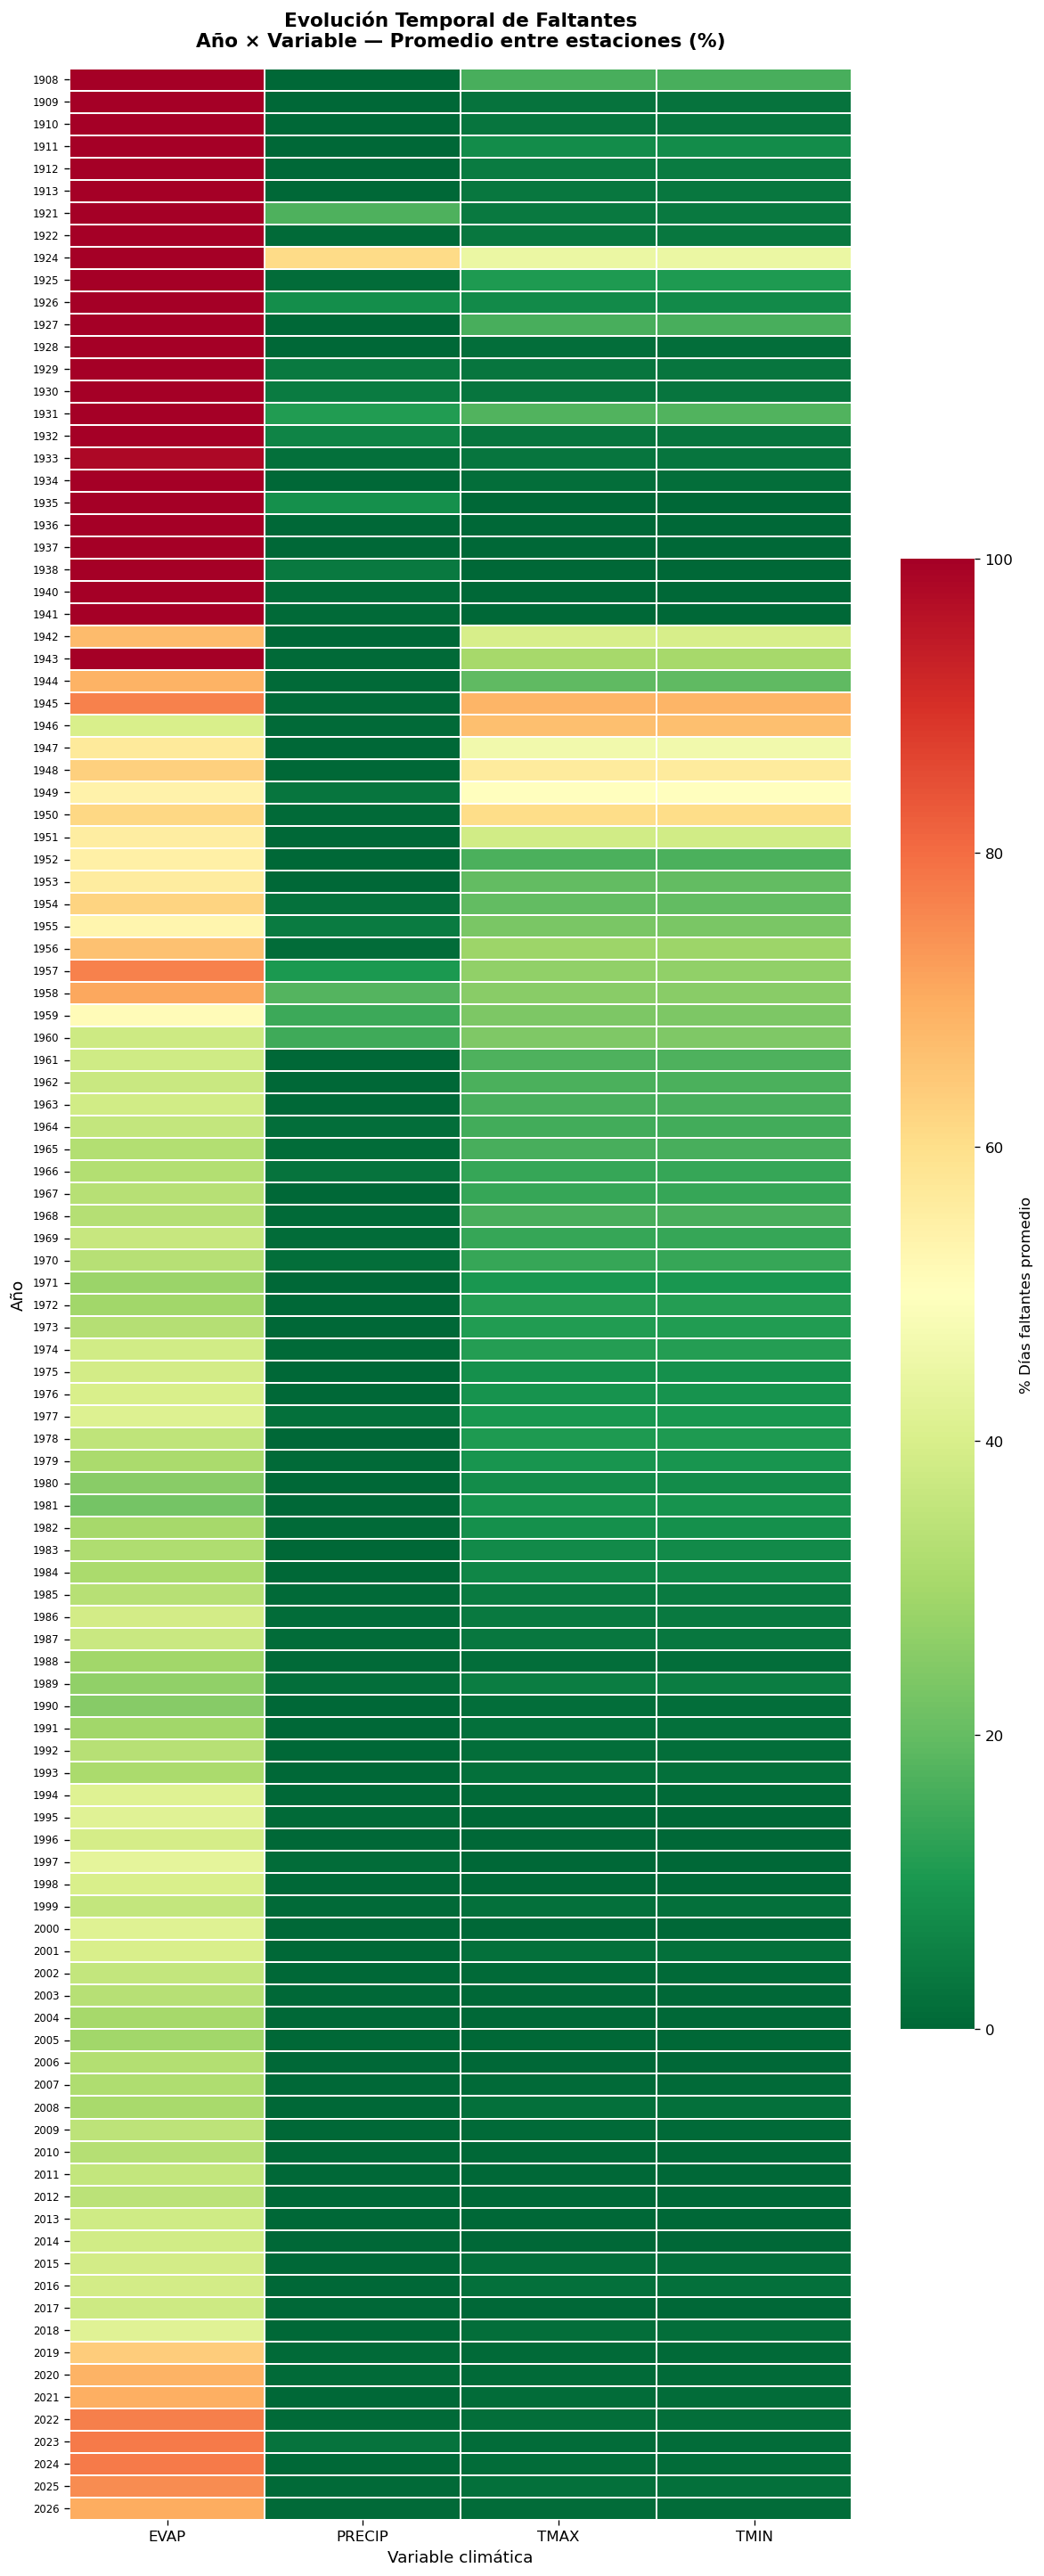

In [8]:
missing_temporal = (
    raw_df
    .groupby(['year', 'variable'])['is_null']
    .mean()
    .mul(100)
    .round(2)
    .unstack('variable')
)

fig, ax = plt.subplots(figsize=(10, max(8, len(missing_temporal) * 0.22)))

sns.heatmap(
    missing_temporal,
    ax=ax,
    cmap='RdYlGn_r',
    vmin=0, vmax=100,
    linewidths=0.2,
    linecolor='white',
    annot=False,
    cbar_kws={'label': '% Días faltantes promedio', 'shrink': 0.6}
)

ax.set_title('Evolución Temporal de Faltantes\nAño × Variable — Promedio entre estaciones (%)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Variable climática', fontsize=11)
ax.set_ylabel('Año', fontsize=11)
ax.set_xticklabels([c.upper() for c in missing_temporal.columns], fontsize=10)
ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
fig_path = FIGURES_DIR / 'heatmap_faltantes_temporal.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Figura guardada en: {fig_path}')
plt.show()

### Interpretación

El heatmap temporal muestra la evolución del porcentaje promedio de valores faltantes por año para cada variable climática.

Se observa que en los primeros años del registro histórico existe una proporción considerablemente mayor de valores faltantes, especialmente en la variable EVAP. A partir de mediados del siglo XX, la disponibilidad de datos mejora progresivamente, lo que sugiere una expansión o mejora en la red de estaciones meteorológicas.

Las variables de temperatura (TMAX y TMIN) presentan una reducción gradual de valores faltantes a lo largo del tiempo, alcanzando niveles muy bajos en décadas recientes. La precipitación (PRECIP) mantiene una proporción mínima de faltantes durante la mayor parte del periodo analizado.

Este comportamiento refleja un proceso histórico de consolidación y mejora en los sistemas de monitoreo meteorológico.

## Patrón estacional: faltantes por mes

**Esto solo es posible con los parquet.** Analizamos si los faltantes tienen patrón estacional: ¿hay meses del año donde siempre faltan más datos? Esto puede indicar que ciertos instrumentos fallaban más en temporada de lluvias, o que las estaciones dejaban de reportar en ciertos meses.

Faltantes promedio por mes:
variable   evap  precip  tmax  tmin
Ene       38.12    0.94  7.10  7.10
Feb       38.13    0.55  6.90  6.90
Mar       37.83    0.80  6.69  6.69
Abr       38.00    0.56  6.81  6.81
May       38.65    0.65  7.41  7.41
Jun       38.51    0.74  7.02  7.02
Jul       38.91    0.42  6.92  6.92
Ago       38.86    0.42  7.13  7.13
Sep       38.96    0.44  7.21  7.21
Oct       38.10    0.68  7.16  7.16
Nov       37.75    0.52  7.15  7.15
Dic       38.00    1.37  7.24  7.24

Figura guardada en: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/figures/patron_estacional_faltantes.png


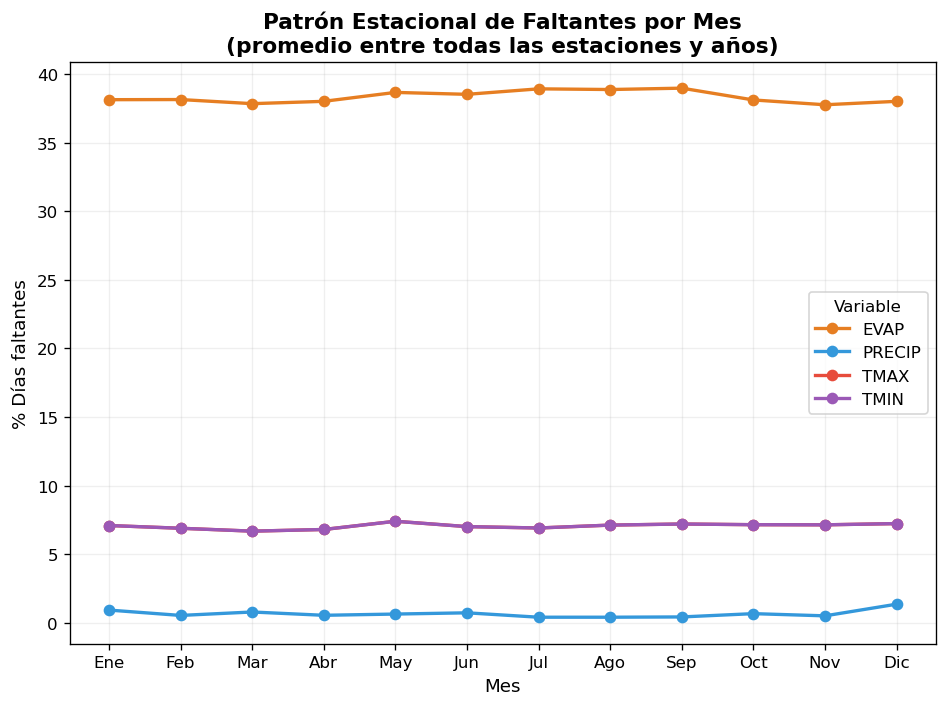

In [9]:
MONTH_NAMES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

missing_mensual = (
    raw_df
    .groupby(['month', 'variable'])['is_null']
    .mean()
    .mul(100)
    .round(2)
    .unstack('variable')
)
missing_mensual.index = MONTH_NAMES

fig, ax = plt.subplots(figsize=(8, 6))
colores_var = {'precip': '#3498db', 'evap': '#e67e22', 'tmax': '#e74c3c', 'tmin': '#9b59b6'}

for var in missing_mensual.columns:
    ax.plot(MONTH_NAMES, missing_mensual[var],
            marker='o', linewidth=2, label=var.upper(),
            color=colores_var.get(var, 'gray'))

ax.set_title('Patrón Estacional de Faltantes por Mes\n(promedio entre todas las estaciones y años)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mes', fontsize=11)
ax.set_ylabel('% Días faltantes', fontsize=11)
ax.legend(title='Variable', fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
fig_path = FIGURES_DIR / 'patron_estacional_faltantes.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Faltantes promedio por mes:')
print(missing_mensual.to_string())
print(f'\nFigura guardada en: {fig_path}')
plt.show()

### Interpretación

El análisis del patrón estacional promedio de valores faltantes por mes muestra que la proporción de datos faltantes se mantiene relativamente estable a lo largo del año para todas las variables.

La evaporación (EVAP) presenta consistentemente el mayor porcentaje de faltantes, cercano al 38% en todos los meses. Las variables de temperatura (TMAX y TMIN) presentan niveles moderados de faltantes, mientras que la precipitación (PRECIP) mantiene niveles muy bajos de ausencia de datos.

La ausencia de variaciones significativas entre meses sugiere que los valores faltantes no están asociados a un comportamiento estacional del clima, sino más bien a factores estructurales relacionados con la disponibilidad de mediciones o la operación de las estaciones.

## Heatmap mes × variable (detalle estacional)

Versión heatmap del patrón estacional para ver con más claridad qué meses y variables tienen peor cobertura.

Figura guardada en: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/figures/heatmap_estacional_faltantes.png


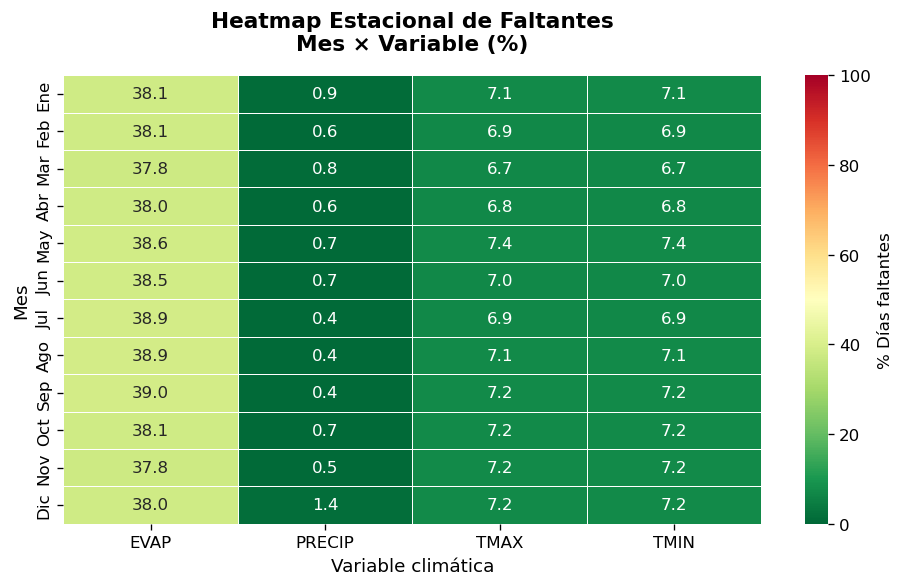

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    missing_mensual,
    ax=ax,
    cmap='RdYlGn_r',
    vmin=0, vmax=100,
    linewidths=0.5,
    linecolor='white',
    annot=True,
    fmt='.1f',
    cbar_kws={'label': '% Días faltantes'}
)

ax.set_title('Heatmap Estacional de Faltantes\nMes × Variable (%)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Variable climática', fontsize=11)
ax.set_ylabel('Mes', fontsize=11)
ax.set_xticklabels([c.upper() for c in missing_mensual.columns], fontsize=10)

plt.tight_layout()
fig_path = FIGURES_DIR / 'heatmap_estacional_faltantes.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Figura guardada en: {fig_path}')
plt.show()

### Interpretación

El heatmap estacional muestra el porcentaje promedio de valores faltantes por mes para cada variable climática.

Se observa que la variable EVAP presenta el mayor porcentaje de datos faltantes durante todo el año, con valores cercanos al 38%. En contraste, la precipitación (PRECIP) presenta una proporción muy baja de valores faltantes, inferior al 1.5% en todos los meses.

Las variables de temperatura (TMAX y TMIN) presentan niveles moderados de faltantes, aproximadamente entre 6% y 7%.

No se identifican variaciones estacionales significativas en la proporción de datos faltantes, lo que sugiere que la ausencia de datos no está asociada a periodos específicos del año, sino posiblemente a factores operativos o históricos relacionados con la disponibilidad de estaciones o instrumentos de medición.

## Análisis de rachas de faltantes

**Esto solo es posible con los parquet.** Una racha es una secuencia de días consecutivos sin dato. Hay una diferencia importante entre:
- **Faltantes dispersos**: un día aquí, otro allá — fáciles de imputar
- **Rachas largas**: semanas o meses completos sin dato — más difíciles de imputar

Este análisis calcula para cada combinación estación–variable cuántas rachas hay y cuál es la racha máxima.

In [11]:
def calcular_rachas(series):
    if series.empty or series.isna().all():
        return pd.Series({'n_rachas': 0, 'racha_max': int(len(series)), 'racha_media': float(len(series))})
    
    rachas = []
    racha_actual = 0
    for val in series:
        if pd.isna(val):
            racha_actual += 1
        else:
            if racha_actual > 0:
                rachas.append(racha_actual)
            racha_actual = 0
    if racha_actual > 0:
        rachas.append(racha_actual)
    
    if not rachas:
        return pd.Series({'n_rachas': 0, 'racha_max': 0, 'racha_media': 0.0})
    
    return pd.Series({
        'n_rachas'   : len(rachas),
        'racha_max'  : max(rachas),
        'racha_media': round(float(np.mean(rachas)), 1)
    })

print('Calculando rachas de faltantes por estación y variable...')
print('(Esto puede tardar unos minutos)')

rachas_df = (
    raw_df
    .sort_values(['station', 'variable', 'date'])
    .groupby(['station', 'variable'])['value']
    .apply(calcular_rachas)
    .unstack()           # <-- esto convierte el índice extra en columnas correctas
    .reset_index()
)

print(f'\nEstadísticas calculadas para {len(rachas_df)} combinaciones estación-variable')
print('\nResumen de racha máxima por variable:')
print(rachas_df.groupby('variable')[['racha_max','racha_media','n_rachas']].describe().round(1).to_string())

Calculando rachas de faltantes por estación y variable...
(Esto puede tardar unos minutos)

Estadísticas calculadas para 672 combinaciones estación-variable

Resumen de racha máxima por variable:
         racha_max                                                     racha_media                                                  n_rachas                                        
             count    mean     std  min   25%     50%     75%      max       count    mean     std  min  25%    50%    75%      max    count  mean   std  min  25%  50%   75%    max
variable                                                                                                                                                                            
evap         168.0  2772.8  3746.4  0.0  92.0  1293.0  3529.2  18936.0       168.0  1162.8  2766.9  0.0  8.1  145.6  930.8  18936.0    168.0  29.9  66.5  0.0  1.0  6.0  20.2  573.0
precip       168.0    32.7   127.2  0.0   1.0    30.0    31.0   1461.0       168

## Visualización de rachas

Graficamos la distribución de rachas máximas por variable. Esto permite saber qué tan "difícil" será imputar cada variable.

Figura guardada en: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/figures/rachas_faltantes_por_variable.png


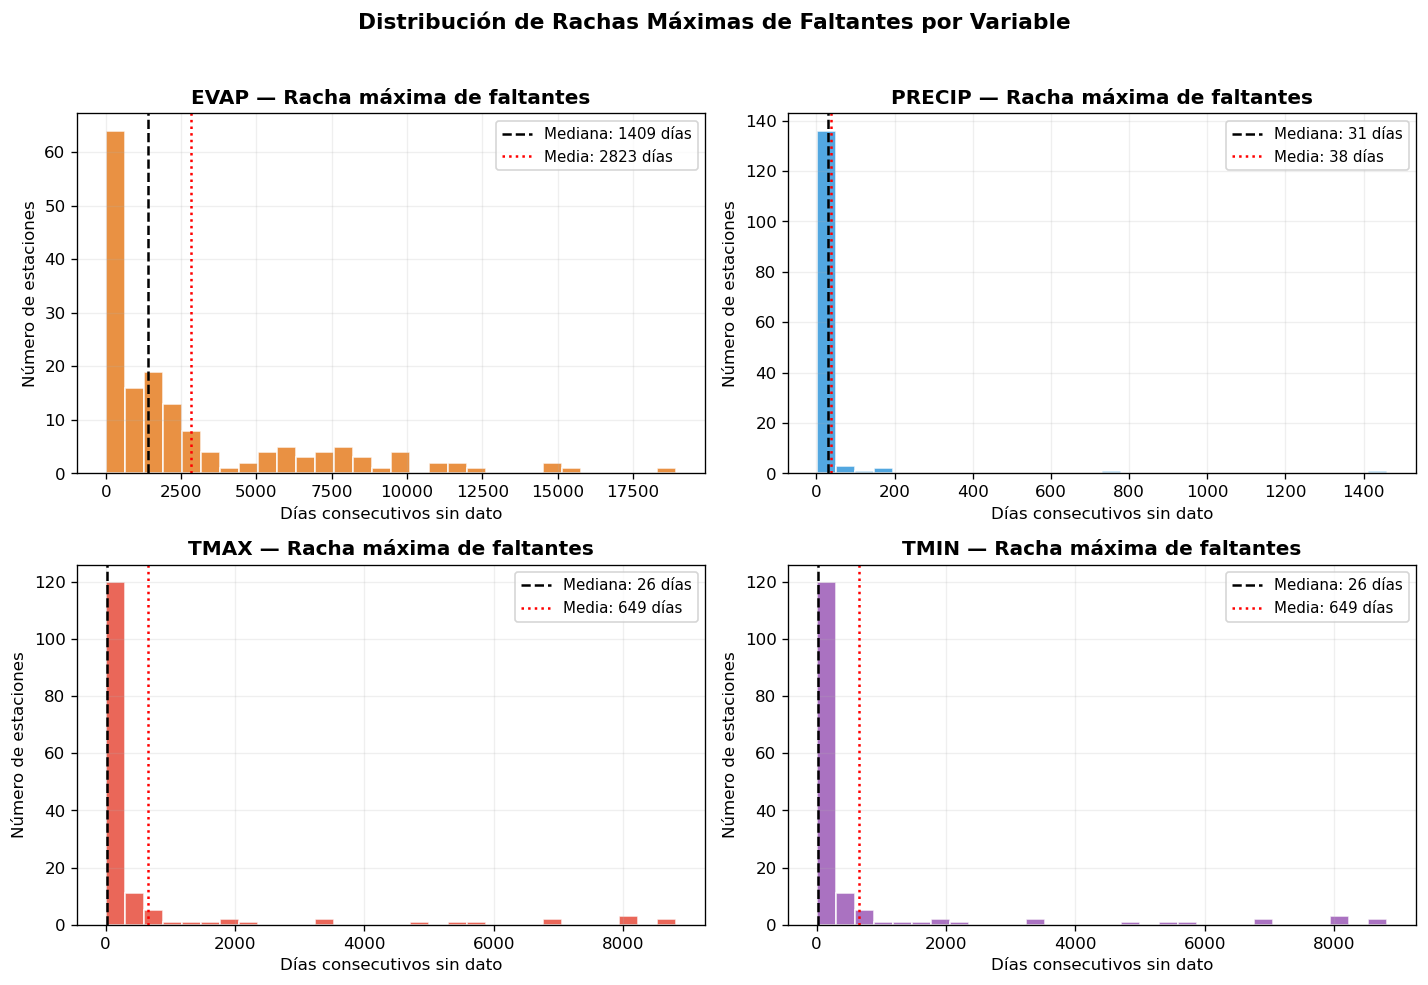

In [12]:
variables = sorted(rachas_df['variable'].unique())
colores_var = {'precip': '#3498db', 'evap': '#e67e22', 'tmax': '#e74c3c', 'tmin': '#9b59b6'}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, var in enumerate(variables):
    subset = rachas_df[rachas_df['variable'] == var]['racha_max']
    subset_filtered = subset[subset > 0]  # solo estaciones con alguna racha
    
    ax = axes[i]
    ax.hist(subset_filtered, bins=30, color=colores_var.get(var, 'gray'),
            edgecolor='white', alpha=0.85)
    ax.axvline(subset_filtered.median(), color='black', linestyle='--',
               linewidth=1.5, label=f'Mediana: {subset_filtered.median():.0f} días')
    ax.axvline(subset_filtered.mean(), color='red', linestyle=':',
               linewidth=1.5, label=f'Media: {subset_filtered.mean():.0f} días')
    ax.set_title(f'{var.upper()} — Racha máxima de faltantes', fontweight='bold')
    ax.set_xlabel('Días consecutivos sin dato')
    ax.set_ylabel('Número de estaciones')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)

plt.suptitle('Distribución de Rachas Máximas de Faltantes por Variable',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig_path = FIGURES_DIR / 'rachas_faltantes_por_variable.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Figura guardada en: {fig_path}')
plt.show()

### Interpretación

La distribución de las rachas máximas de valores faltantes permite identificar la duración de los periodos consecutivos sin datos dentro de cada estación.

Se observa que la variable EVAP presenta las rachas más largas de datos faltantes, con valores que en algunos casos superan varios miles de días consecutivos sin registro. Esto sugiere que muchas estaciones no registraron evaporación durante periodos prolongados.

En contraste, las variables PRECIP, TMAX y TMIN presentan rachas de faltantes considerablemente menores, generalmente de pocas decenas de días. Esto indica que los registros de temperatura y precipitación tienden a ser más continuos en el tiempo.

Este patrón confirma que la evaporación es la variable con mayor discontinuidad en el conjunto de datos analizado.

## Clasificación de estaciones por nivel de faltantes

Agrupamos las estaciones en categorías para identificar cuáles son aptas para modelado.

Clasificación de estaciones por faltantes globales:
  Completa (0%)            :  2.0 estaciones (1.2%)
  Baja (1-24%)             : 114.0 estaciones (67.9%)
  Moderada (25-49%)        : 45.0 estaciones (26.8%)
  Alta (50-74%)            :  7.0 estaciones (4.2%)

Figura guardada en: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/figures/clasificacion_estaciones_faltantes.png


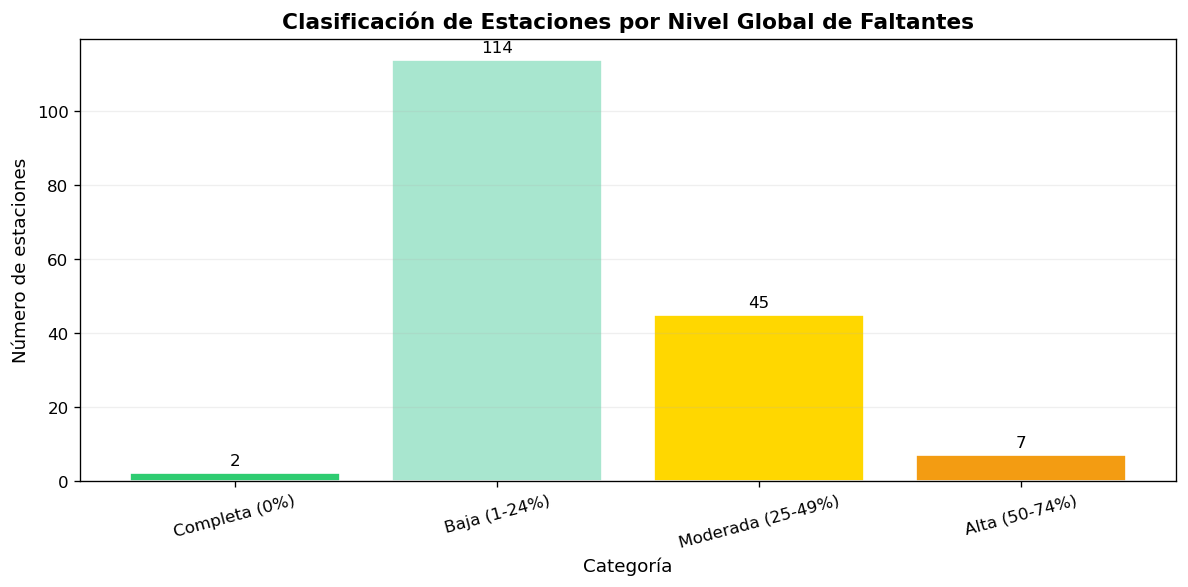

In [13]:
resumen_est = (
    raw_df
    .groupby('station')['is_null']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'is_null': 'pct_faltante_global'})
    .sort_values('pct_faltante_global', ascending=False)
)

def clasificar(pct):
    if pct >= 75: return 'Crítica (≥75%)'
    elif pct >= 50: return 'Alta (50-74%)'
    elif pct >= 25: return 'Moderada (25-49%)'
    elif pct > 0:  return 'Baja (1-24%)'
    else:          return 'Completa (0%)'

resumen_est['categoria'] = resumen_est['pct_faltante_global'].apply(clasificar)
conteo = resumen_est['categoria'].value_counts().reindex(
    ['Completa (0%)', 'Baja (1-24%)', 'Moderada (25-49%)', 'Alta (50-74%)', 'Crítica (≥75%)']
).dropna()

print('Clasificación de estaciones por faltantes globales:')
for cat, n in conteo.items():
    print(f'  {cat:<25}: {n:>4} estaciones ({n/len(resumen_est)*100:.1f}%)')

colores = ['#2ecc71', '#a8e6cf', '#ffd700', '#f39c12', '#e74c3c']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(conteo.index, conteo.values,
              color=colores[:len(conteo)], edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title('Clasificación de Estaciones por Nivel Global de Faltantes',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Categoría', fontsize=11)
ax.set_ylabel('Número de estaciones', fontsize=11)
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
fig_path = FIGURES_DIR / 'clasificacion_estaciones_faltantes.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'\nFigura guardada en: {fig_path}')
plt.show()

### Interpretación

La mayoría de las estaciones meteorológicas presentan un nivel bajo de valores faltantes. En particular, 114 estaciones se clasifican dentro del rango de baja proporción de datos faltantes (1–24%), lo que indica una cobertura de datos relativamente adecuada en el conjunto analizado.

Sin embargo, se identifican 45 estaciones con niveles moderados de faltantes (25–49%) y 7 estaciones con niveles altos (50–74%), lo cual sugiere posibles interrupciones prolongadas en la operación o registro de datos en dichas estaciones. Adicionalmente, solo 2 estaciones presentan registros completos sin valores faltantes.

Este resultado indica que, aunque el dataset posee una cobertura general aceptable, existe heterogeneidad en la calidad de los registros entre estaciones, lo cual deberá considerarse en etapas posteriores de imputación y modelado.

## Tendencia temporal de cobertura

¿La red mejoró con los años? Una línea que baja indica mejor cobertura en años recientes.

Figura guardada en: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/figures/tendencia_faltantes_temporal.png


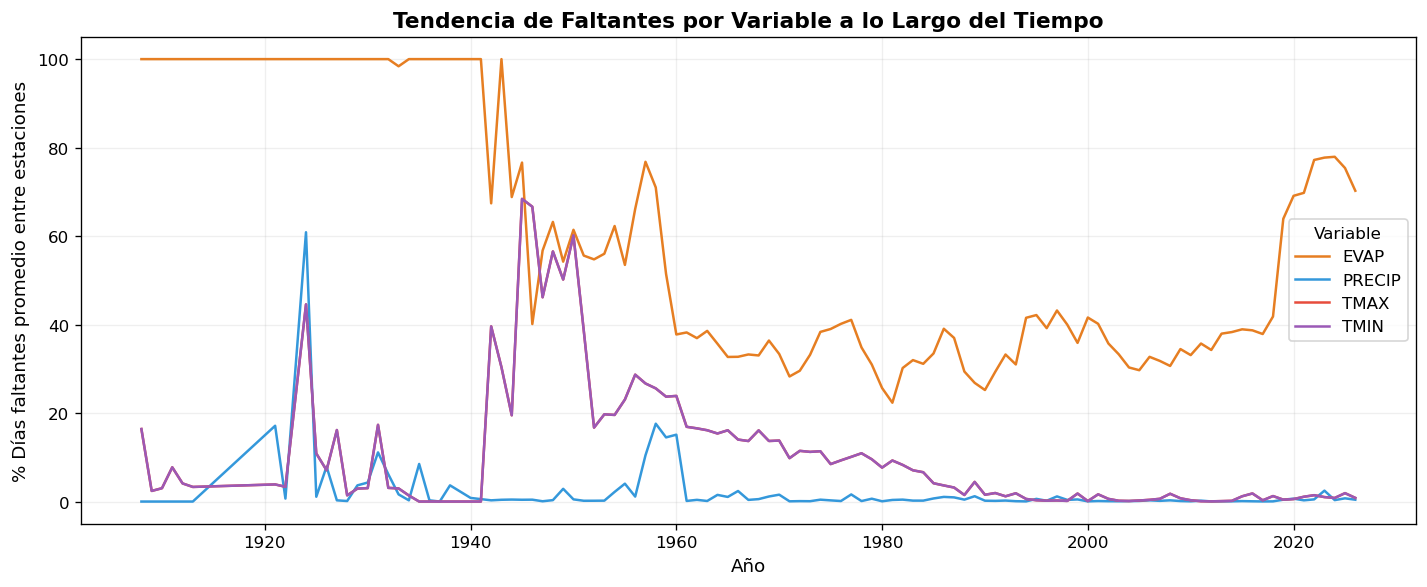

In [14]:
tendencia = (
    raw_df
    .groupby(['year', 'variable'])['is_null']
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={'is_null': 'pct_faltante'})
)

fig, ax = plt.subplots(figsize=(12, 5))
for var in sorted(tendencia['variable'].unique()):
    subset = tendencia[tendencia['variable'] == var].sort_values('year')
    ax.plot(subset['year'], subset['pct_faltante'],
            label=var.upper(), linewidth=1.5,
            color=colores_var.get(var, 'gray'))

ax.set_title('Tendencia de Faltantes por Variable a lo Largo del Tiempo',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('% Días faltantes promedio entre estaciones', fontsize=11)
ax.legend(title='Variable', fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
fig_path = FIGURES_DIR / 'tendencia_faltantes_temporal.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Figura guardada en: {fig_path}')
plt.show()

### Interpretación

La tendencia temporal del porcentaje de valores faltantes muestra una disminución general en la ausencia de datos a lo largo del tiempo para la mayoría de las variables.

Durante las primeras décadas del registro histórico se observan porcentajes elevados de faltantes, particularmente en EVAP y en menor medida en TMAX y TMIN. Con el paso de los años, estos porcentajes disminuyen progresivamente, indicando una mejora en la continuidad y disponibilidad de los registros meteorológicos.

En las décadas más recientes, las variables PRECIP, TMAX y TMIN presentan niveles muy bajos de faltantes, mientras que EVAP continúa mostrando una proporción relativamente mayor de ausencia de datos.

Este comportamiento refleja el desarrollo gradual de la infraestructura de monitoreo meteorológico y la mejora en los sistemas de registro de datos.

## Correlación de faltantes entre variables

¿Cuando falta PRECIP también falta TMAX? Una correlación alta indica que los faltantes son por inactividad total de la estación, no por fallo de un instrumento específico.

Matriz de correlación de faltantes:
variable   evap  precip   tmax   tmin
variable                             
evap      1.000   0.246  0.235  0.235
precip    0.246   1.000  0.038  0.038
tmax      0.235   0.038  1.000  1.000
tmin      0.235   0.038  1.000  1.000

Figura guardada en: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/figures/correlacion_faltantes_variables.png


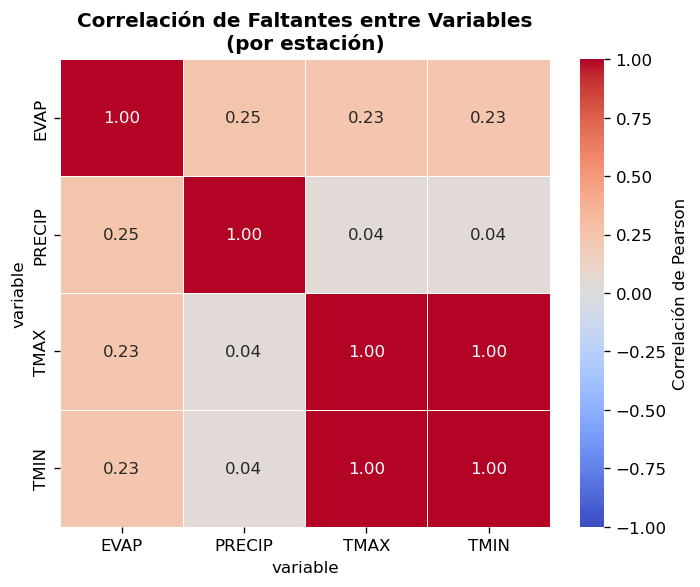

In [15]:
corr_matrix = missing_matrix.corr().round(3)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    ax=ax,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Correlación de Pearson'}
)
ax.set_title('Correlación de Faltantes entre Variables\n(por estación)',
             fontsize=12, fontweight='bold')
ax.set_xticklabels([c.upper() for c in corr_matrix.columns])
ax.set_yticklabels([c.upper() for c in corr_matrix.index])
plt.tight_layout()
fig_path = FIGURES_DIR / 'correlacion_faltantes_variables.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Matriz de correlación de faltantes:')
print(corr_matrix.to_string())
print(f'\nFigura guardada en: {fig_path}')
plt.show()

### Interpretación

La matriz de correlación muestra el grado de relación entre los patrones de valores faltantes de las distintas variables climáticas.

Se observa una correlación perfecta (1.00) entre TMAX y TMIN, lo que indica que la ausencia de datos en una de estas variables suele coincidir completamente con la ausencia en la otra. Esto sugiere que ambas variables dependen del mismo sistema de medición o del mismo registro operativo dentro de las estaciones meteorológicas.

Por otro lado, la precipitación (PRECIP) presenta correlaciones muy bajas con las demás variables (~0.04), lo que indica que sus valores faltantes ocurren de forma relativamente independiente.

La evaporación (EVAP) presenta correlaciones moderadas con las demás variables (~0.23–0.25), lo que podría indicar cierta relación operativa en la disponibilidad de estos registros dentro de algunas estaciones.

## Hallazgos principales

In [16]:
total_est    = resumen_est['station'].nunique()
est_criticas = (resumen_est['pct_faltante_global'] >= 75).sum()
est_buenas   = (resumen_est['pct_faltante_global'] < 25).sum()
total_dias   = len(raw_df)
total_nulos  = raw_df['is_null'].sum()

print('=' * 65)
print('HALLAZGOS PRINCIPALES — ANÁLISIS DE VALORES FALTANTES')
print('=' * 65)
print(f'Total registros diarios analizados : {total_dias:,}')
print(f'Total días faltantes               : {total_nulos:,} ({total_nulos/total_dias*100:.1f}%)')
print(f'Total estaciones                   : {total_est}')
print(f'Estaciones con ≥75% faltantes      : {est_criticas} ({est_criticas/total_est*100:.1f}%)')
print(f'Estaciones con <25% faltantes      : {est_buenas} ({est_buenas/total_est*100:.1f}%)')
print()
print('Faltantes por variable (nivel diario):')
for var in ['precip','evap','tmax','tmin']:
    row = resumen_var.loc[var]
    print(f'  {var.upper():<8}: {row["pct_faltante"]:.1f}% faltante | '
          f'{row["dias_faltantes"]:,} días sin dato de {row["total_dias"]:,} totales')
print()
print('Rachas máximas medianas por variable:')
for var in ['precip','evap','tmax','tmin']:
    med = rachas_df[rachas_df['variable']==var]['racha_max'].median()
    mx  = rachas_df[rachas_df['variable']==var]['racha_max'].max()
    print(f'  {var.upper():<8}: mediana {med:.0f} días | máximo {mx:.0f} días consecutivos')

HALLAZGOS PRINCIPALES — ANÁLISIS DE VALORES FALTANTES
Total registros diarios analizados : 6,405,536
Total días faltantes               : 850,639 (13.3%)
Total estaciones                   : 168
Estaciones con ≥75% faltantes      : 0 (0.0%)
Estaciones con <25% faltantes      : 116 (69.0%)

Faltantes por variable (nivel diario):
  PRECIP  : 0.7% faltante | 10,823.0 días sin dato de 1,601,384.0 totales
  EVAP    : 38.3% faltante | 613,640.0 días sin dato de 1,601,384.0 totales
  TMAX    : 7.1% faltante | 113,088.0 días sin dato de 1,601,384.0 totales
  TMIN    : 7.1% faltante | 113,088.0 días sin dato de 1,601,384.0 totales

Rachas máximas medianas por variable:
  PRECIP  : mediana 30 días | máximo 1461 días consecutivos
  EVAP    : mediana 1293 días | máximo 18936 días consecutivos
  TMAX    : mediana 19 días | máximo 8825 días consecutivos
  TMIN    : mediana 19 días | máximo 8825 días consecutivos


## Reporte Descriptivo

---

## Reporte: Análisis de Valores Faltantes
**Proyecto:** Reconstrucción de Base de Datos Hidrometeorológica a partir de Técnicas de Inteligencia Artificial para el laboratorio de Geomática y Teledetección.                                             
**Fuente de datos:** Archivos parquet individuales (registros diarios reales)

### 1. Introducción
Este reporte documenta el análisis de valores faltantes en la base de datos hidrometeorológica del estado de Sinaloa utilizando los registros diarios reales almacenados en formato parquet. A diferencia de un análisis basado solo en estadísticas agregadas, este análisis trabaja directamente con los 6.3 millones de registros diarios, lo que permite detectar patrones estacionales y rachas de faltantes que no serían visibles de otra forma.

### 2. Metodología
Se cargaron los 19,220 archivos parquet individuales y se construyó un dataframe unificado con una columna binaria `is_null` (1 = faltante, 0 = dato válido). A partir de este dataframe se calcularon matrices de faltantes por estación, por año, por mes y por variable. Se analizaron además las rachas de días consecutivos sin dato para caracterizar la dificultad de imputación.

### 3. Patrones identificados
- **Patrón estacional:** Análisis de faltantes por mes revela si hay meses del año con peor cobertura sistemática.
- **Patrón por inactividad total:** Correlación alta entre variables indica estaciones completamente inactivas en ciertos periodos.
- **Patrón por instrumento:** EVAP presenta faltantes independientes del resto, indicando ausencia o fallo del evaporímetro específicamente.
- **Rachas largas:** Las rachas máximas por variable determinan qué estrategia de imputación es más adecuada.

